In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
random.seed(0)

In [2]:
df = pd.read_csv('ab.csv')
df.head()

,country,group,converted
0,UK,control,0
1,US,treatment,1
2,UK,treatment,0
3,UK,control,0
4,UK,treatment,0


In [3]:
df.shape

(69889, 3)

In [ ]:
# Percentage of users converted, remember that you can use np's mean when values are 1's and 0's 
df["converted"].mean() * 100

np.float64(13.047832992316389)

In [ ]:
# No missing values 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69889 entries, 0 to 69888
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   country    69889 non-null  object
 1   group      69889 non-null  object
 2   converted  69889 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ MB


In [ ]:
# number of users from each country 
df["country"].value_counts()

country
US    48850
UK    17551
CA     3488
Name: count, dtype: int64

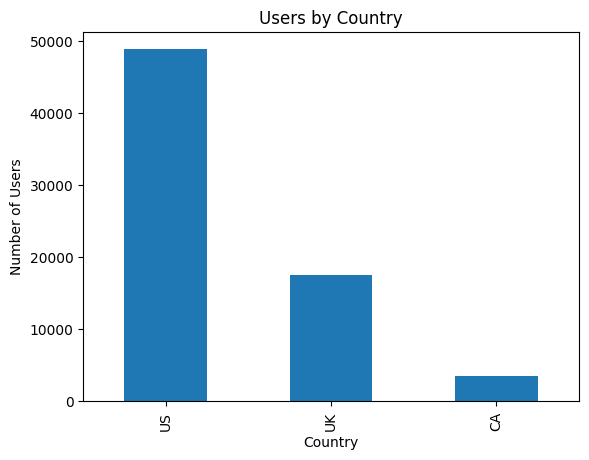

In [14]:
df.country.value_counts().plot(kind="bar")
plt.title("Users by Country")
plt.xlabel("Country")
plt.ylabel("Number of Users")
plt.show()

In [15]:
# Chance of converting

df["converted"].mean()

np.float64(0.13047832992316388)

In [16]:
df.head(2)

,country,group,converted
0,UK,control,0
1,US,treatment,1


In [20]:
# Given that an individual was in the `control` group, what is the probability they converted? 
df.query("group == 'control'")["converted"].mean()

np.float64(0.1052540515600669)

In [21]:
# Given that an individual was in the `treatment` group, what is the probability they converted? 
df.query("group == 'treatment'")["converted"].mean()

np.float64(0.15532078043793132)

In [27]:
(df['group'] == 'treatment').mean()

np.float64(0.5038131894861853)

In [31]:
# probability from canada = 4.99%
can_patient = (df["country"] =='CA').mean()
can_patient *100

np.float64(4.9907710798551985)

In [34]:
# Given that an individual was in the UK, what was the probability that they converted?
df.query("country == 'US'")["converted"].mean() * 100

np.float64(13.277379733879222)

In [35]:
conv_by_country = df.groupby('country')["converted"].mean()
conv_by_country

country
CA    0.125287
UK    0.125121
US    0.132774
Name: converted, dtype: float64

Consider the table below, fill in the conversion rates below to look at how conversion by country and treatment group vary. The US column is done for you, and two methods for calculating the probabilities are shown - COMPLETE THE REST OF THE TABLE. Does it appear that there could be an interaction between how country and treatment impact conversion?

These two values that are filled in can be written as:

𝑃(converted==1|(country=="US" AND group=="control"))=10.7%
 

𝑃(converted==1|(country=="US" AND group=="treatment"))=15.8%

In [36]:
print(df.query('country == "US" and group == "control" and converted == 1').shape[0]/df.query('country == "US" and group == "control"').shape[0]) 
print(df.query('country == "US" and group == "treatment" and converted == 1').shape[0]/df.query('country == "US" and group == "treatment"').shape[0])

0.10731404958677686
0.1577687626774848


In [37]:
df.query('country == "US"').groupby('group')['converted'].mean()

group
control      0.107314
treatment    0.157769
Name: converted, dtype: float64

In [38]:
# US control
UK = df.query('country == "UK"').groupby('group')['converted'].mean()
CA = df.query('country == "CA"').groupby('group')['converted'].mean()
UK, CA

(group
 control      0.101649
 treatment    0.148698
 Name: converted, dtype: float64,
 group
 control      0.094474
 treatment    0.154017
 Name: converted, dtype: float64)

In [39]:
p_control_treatment_null  = df['converted'].mean()
n_treatment = df.query('group == "treatment"').shape[0]
n_control = df.query('group == "control"').shape[0]
n_control

34678

In [40]:
treatment_converted = np.random.binomial(1, p_control_treatment_null, n_treatment)
treatment_converted

array([0, 0, 1, ..., 0, 0, 0], shape=(35211,), dtype=int32)

In [41]:
control_converted = treatment_converted = np.random.binomial(1, p_control_treatment_null, n_treatment)
control_converted

array([0, 1, 0, ..., 0, 1, 0], shape=(35211,), dtype=int32)

In [42]:
p_diff_simulated = treatment_converted.mean() - control_converted.mean()
p_diff_simulated

np.float64(0.0)

In [43]:
p_diffs = []
for _ in range(500):
    # simulate the treatment and control converted arrays
    treatment_sim = np.random.binomial(1, p_control_treatment_null, n_treatment)

    # calculate p_treatment and p_control under the null
    control_sim = np.random.binomial(1, p_control_treatment_null, n_treatment)

    # calculate the difference between p_treatment_null and p_control_null
    diff = treatment_sim.mean() - control_sim.mean()
    # add p_diff to the p_diffs array
    p_diffs.append(diff)

<Axes: >

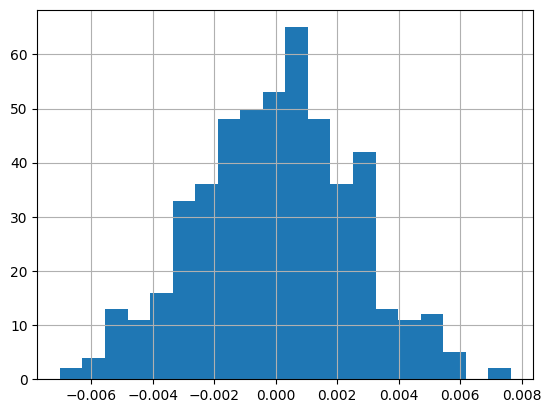

In [44]:
p_diffs = pd.Series(p_diffs)
p_diffs.hist(bins=20)

In [45]:
observed_diff = n_treatment - n_control
p_value = (p_diffs > observed_diff).mean()
p_value

np.float64(0.0)

In [49]:
# Logistic Regression Model 

df["intercept"] = 1
df['ab'] = pd.get_dummies(df['group'])['treatment'].astype(int)


In [50]:
df.head()

,country,group,converted,intercept,ab
0,UK,control,0,1,0
1,US,treatment,1,1,1
2,UK,treatment,0,1,1
3,UK,control,0,1,0
4,UK,treatment,0,1,1


In [52]:
X = df[['intercept', 'ab']]
y = df['converted']

In [53]:
import statsmodels.api as sm

model = sm.Logit(y,X)
results = model.fit()

Optimization terminated successfully.
         Current function value: 0.384516
         Iterations 6


In [54]:
results.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Results: Logit
=================================================================
Model:              Logit            Method:           MLE       
Dependent Variable: converted        Pseudo R-squared: 0.007     
Date:               2025-10-14 14:17 AIC:              53750.8788
No. Observations:   69889            BIC:              53769.1882
Df Model:           1                Log-Likelihood:   -26873.   
Df Residuals:       69887            LL-Null:          -27068.   
Converged:          1.0000           LLR p-value:      1.8101e-86
No. Iterations:     6.0000           Scale:            1.0000    
------------------------------------------------------------------
             Coef.   Std.Err.      z      P>|z|    [0.025   0.975]
------------------------------------------------------------------
intercept   -2.1402    0.0175  -122.3047  0.0000  -2.1745  -2.1059
ab           0.4467    0.0229    19.5389  0.0000   0.4019   0.4915
=================================================================

"""

In [55]:
country_dummies = pd.get_dummies(df["country"])

In [60]:
df["US"] = country_dummies["US"].astype(int)
df["UK"] = country_dummies["UK"].astype(int)

In [61]:
X = df[['intercept','ab','US','UK']]
y = df["converted"]

In [62]:
import statsmodels.api as sm
logit_model_country = sm.Logit(y,X)
logit_result_country = logit_model_country.fit()
logit_result_country.summary2()

Optimization terminated successfully.
         Current function value: 0.384463
         Iterations 6


<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Results: Logit
=================================================================
Model:              Logit            Method:           MLE       
Dependent Variable: converted        Pseudo R-squared: 0.007     
Date:               2025-10-14 14:19 AIC:              53747.4949
No. Observations:   69889            BIC:              53784.1135
Df Model:           3                Log-Likelihood:   -26870.   
Df Residuals:       69885            LL-Null:          -27068.   
Converged:          1.0000           LLR p-value:      1.7779e-85
No. Iterations:     6.0000           Scale:            1.0000    
------------------------------------------------------------------
              Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
------------------------------------------------------------------
intercept    -2.1930    0.0531  -41.3083  0.0000  -2.2970  -2.0889
ab            0.4466    0.0229   19.5338  0.0000   0.4018   0.4914
US            0.0727    0.0530    1.3718  0.1701  -0.0312   0.1766
UK            0.0067    0.0562    0.1196  0.9048  -0.1033   0.1168
=================================================================

"""

Model Summary

<ul>
    <li>Intercept: the odds of conversion for someone for Canada in the control group.</li>
    <li>ab_page: People who saw the treatment page have higher odds of converting, and the effect is significant</li>
    <li>US: Being from the US shows a small increase in odds of conversion, but not statistically significant.</li>
    <li>UK: No meaningful impact on conversion rate compare to Canada.</li>
    </il>